In [40]:
import pandas as pd
from sqlalchemy import create_engine
import json
import datetime as dt
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [41]:
## Load data transaksi.csv
df = pd.read_csv('transaksi.csv',
                 dtype={'customer_id': str, 'product_id': str,'name': str },
                 parse_dates=['order_date'])
df

,order_id,customer_id,name,order_date,total_amount,coupon_code
0,ORD00001,CUST00410,Gandewa Setiawan,2026-02-27,784000,DISC 50
1,ORD00002,CUST03658,Ilsa Gunawan,2026-05-06,167000,NONE
2,ORD00003,CUST08936,Kemal Namaga,2026-02-22,114000,NONE
3,ORD00004,CUST00521,Emas Hidayanto,2026-08-05,55000,DISC10
4,ORD00005,CUST03812,Sadina Suartini,2026-04-22,542000,NONE
...,...,...,...,...,...,...
9995,ORD09996,CUST00158,Maman Susanti,2026-08-30,876000,NONE
9996,ORD09997,CUST07324,Prayogo Nainggolan,2026-01-11,72000,DISCC20
9997,ORD09998,CUST08523,Yessi Gunawan,2026-09-07,820000,DISC10
9998,ORD09999,CUST08391,Virman Sihombing,2026-09-28,794000,NONE


In [42]:
## Load data CRM
print('[INFO] menghubungkan ke database...')
db_url = 'postgresql://postgres:pw@localhost:5432/data_wringling'
engine = create_engine(db_url)

query = """
select customer_id,customer_name,membership_tier, city
from customers
where is_active = 1
"""
df_crm = pd.read_sql(query, con=engine)

[INFO] menghubungkan ke database...


In [43]:
# Load data logistik.json dari API online
api_url = 'https://gist.githubusercontent.com/BuhLah12/1ceb42f12fa973cbb3e3be2770c8c541/raw/3ce25c3087df2798630aa014001c2961b7eb1558/data_logistik.json'
try:
    response = requests.get(api_url, timeout=5)
    if response.status_code == 200:
        data_logistik = response.json()
        print("[INFO] Berhasil mengakses API online, data_logistik.json berhasil diambil.")
    else:
        raise Exception(f"Request failed with status code: {response.status_code}")
except Exception as e:
    print(f"[WARN] Gagal akses API online ({e}), membaca data_logistik.json lokal...")
    with open('data_logistik.json', 'r') as f:
        data_logistik = json.load(f)

# Panggil langsung data_logistik["results"] tanpa memakai .json
df_logistik = pd.json_normalize(data_logistik['results'])

[INFO] Berhasil mengakses API online, data_logistik.json berhasil diambil.


In [44]:
# Integrasi Data
print ('[INFO] memproses integrasi data...')
#hapus duplikasi data berdasarkan order_id, simpan yang terakhir
df_logistik = df_logistik.drop_duplicates(subset=['order_id'], keep='last')
#inner join df dan df_crm berdasarkan customer_id, left join df_logistik berdasarkan order_id
df_master = df.merge(df_crm, how='inner', on='customer_id').merge(df_logistik,how = 'left',on = 'order_id')
#hapus duplikasi data berdasarkan order_id, simpan yang terakhir
df_master = df_master.drop_duplicates(subset=['order_id'], keep='last')

print(f'[SUCCESS] integrasi data selesai, total record: {len(df_master)}')

[INFO] memproses integrasi data...
[SUCCESS] integrasi data selesai, total record: 4915


In [45]:
# Buat kamus data
def generate_data_dictionary(df):
    data_list = []
    for col in df.columns:
        data_list.append({
            "Nama Kolom": col,
            "Tipe Data": str(df[col].dtype),
            "Missing Values": df[col].isnull().sum(),
            "Jumlah Unik": df[col].nunique(),
            "Contoh Nilai": df[col].dropna().unique()[:5].tolist()
        })
    return pd.DataFrame(data_list)
#simpan kamus data ke file CSV
kamus_df = generate_data_dictionary(df_master)
kamus_df.to_csv('kamus_data.csv', index=False)
print('[INFO] kamus data berhasil dibuat dan disimpan sebagai kamus_data.csv')

# validasi data
assert df_master['order_id'].is_unique, "Fatal : Terdeteksi order_id yang duplikat, periksa data transaksi.csv"
assert (df_master['total_amount'] >= 0).all(), "Fatal : Terdeteksi nilai transaksi negatif, periksa data transaksi.csv"
assert df_master[df_master['order_date'] <= dt.datetime.now()].shape[0] == df_master.shape[0], "Fatal : Terdeteksi tanggal pesanan di masa depan, periksa data transaksi.csv"

print('[INFO] semua validasi data berhasil tanpa kesalahan')

[INFO] kamus data berhasil dibuat dan disimpan sebagai kamus_data.csv
[INFO] semua validasi data berhasil tanpa kesalahan


In [46]:
dt = pd.read_csv('kamus_data.csv')

In [47]:
dt

,Nama Kolom,Tipe Data,Missing Values,Jumlah Unik,Contoh Nilai
0,order_id,str,0,4915,"['ORD00006', 'ORD00007', 'ORD00008', 'ORD00010..."
1,customer_id,str,0,2867,"['CUST09196', 'CUST03612', 'CUST00107', 'CUST0..."
2,name,str,0,4806,"['Artanto Wacana', 'Cager Hartati', 'Raina Riy..."
3,order_date,datetime64[us],0,275,"[Timestamp('2026-01-14 00:00:00'), Timestamp('..."
4,total_amount,int64,0,969,"[228000, 484000, 802000, 129000, 392000]"
5,coupon_code,str,0,4,"['NONE', 'DISCC20', 'DISC10', 'DISC 50']"
6,customer_name,str,0,2855,"['H. Abyasa Thamrin', 'dr. Darmaji Hassanah', ..."
7,membership_tier,str,0,4,"['Platinum', 'Gold', 'Bronze', 'Silver']"
8,city,str,0,99,"['Purwokerto', 'Semarang', 'Samarinda', 'Mojok..."
9,tracking_number,str,0,4915,"['LOG-00006-ID', 'LOG-00007-ID', 'LOG-00008-ID..."


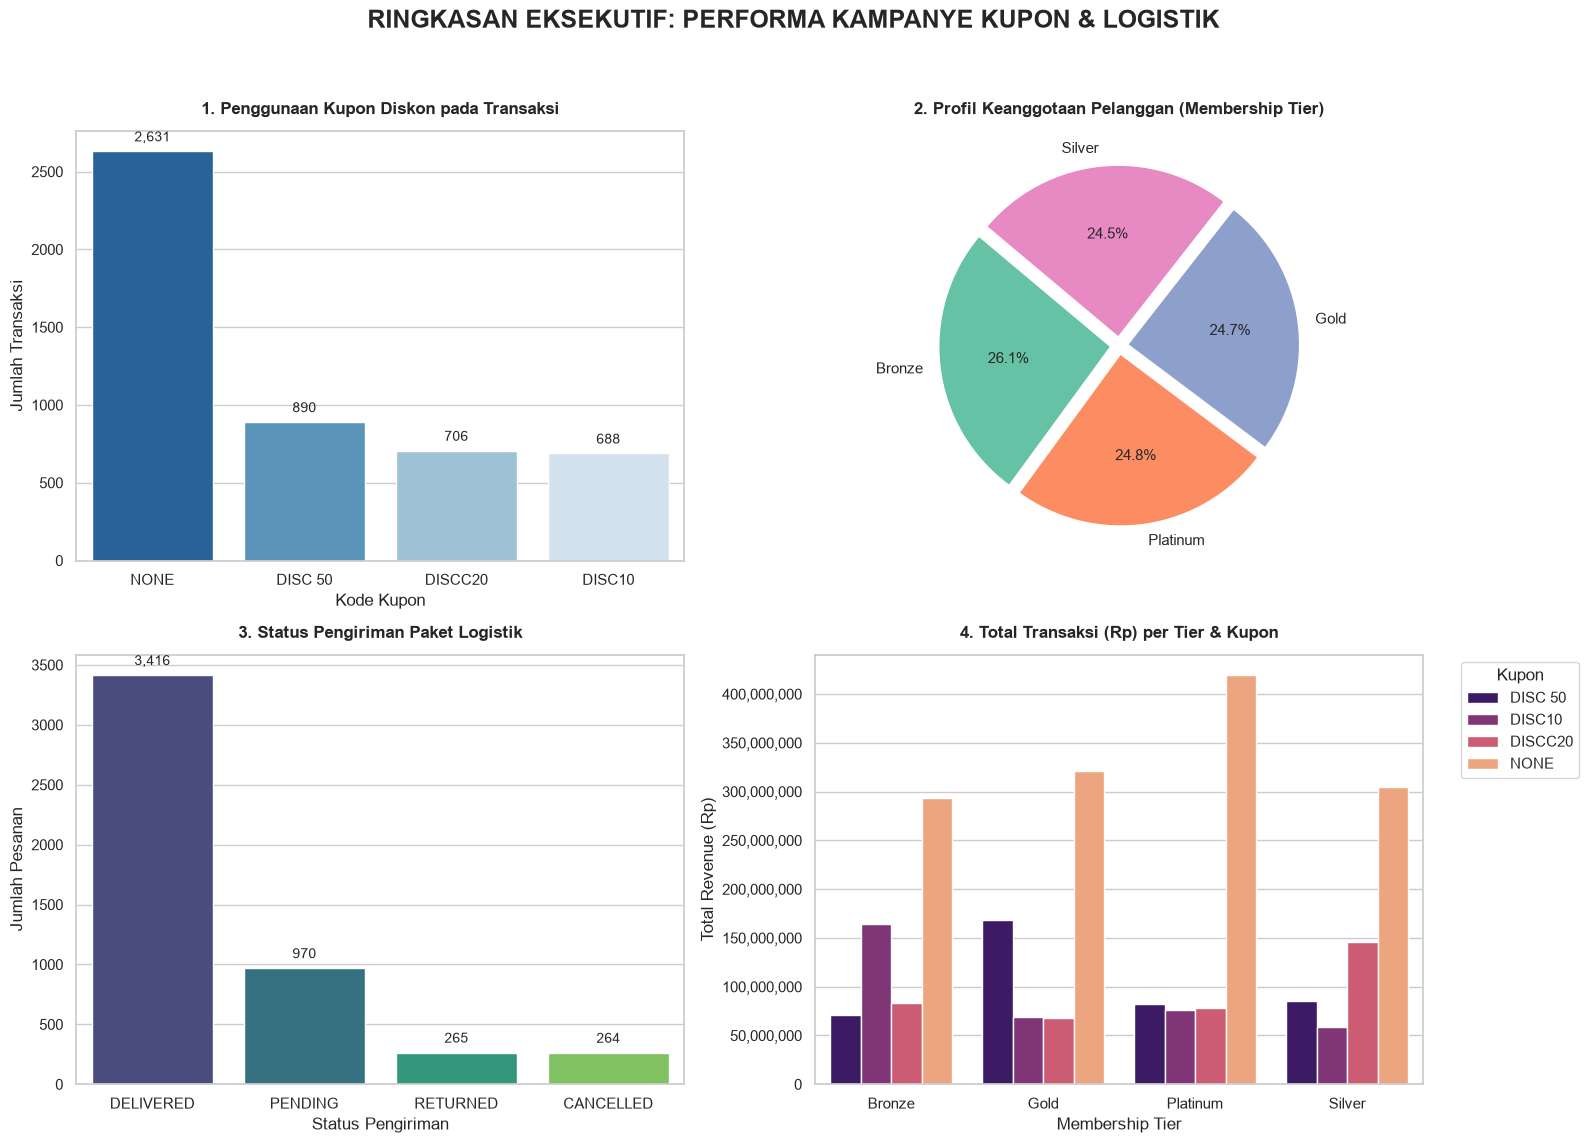

[INFO] Visualisasi berhasil dibuat dan disimpan sebagai 'dashboard_performa_retail.png'


In [48]:
# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Membuat Figure dengan Grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RINGKASAN EKSEKUTIF: PERFORMA KAMPANYE KUPON & LOGISTIK', fontsize=18, fontweight='bold', y=0.98)


# Visualisasi 1: Distribusi Penggunaan Kupon Diskon

coupon_counts = df_master['coupon_code'].value_counts().reset_index()
coupon_counts.columns = ['coupon_code', 'count']

sns.barplot(
    data=coupon_counts,
    x='coupon_code', 
    y='count',
    hue='coupon_code',
    ax=axes[0, 0], 
    palette="Blues_r",
    legend=False
)
axes[0, 0].set_title('1. Penggunaan Kupon Diskon pada Transaksi', fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Kode Kupon')
axes[0, 0].set_ylabel('Jumlah Transaksi')

for p in axes[0, 0].patches:
    if p.get_height() > 0:
        axes[0, 0].annotate(f'{int(p.get_height()):,}', 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                            textcoords='offset points')


# Visualisasi 2: Profil Loyalitas Pelanggan (Membership Tier)
tier_counts = df_master['membership_tier'].value_counts()

axes[0, 1].pie(
    tier_counts.values, 
    labels=tier_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Set2"),
    explode=[0.05] * len(tier_counts)
)
axes[0, 1].set_title('2. Profil Keanggotaan Pelanggan (Membership Tier)', fontweight='bold', pad=12)

# Visualisasi 3: Status Pengiriman Logistik (Dibereskan 'viridis' huruf kecil)
status_counts = df_master['delivery_status'].value_counts(dropna=False).fillna('UNKNOWN').reset_index()
status_counts.columns = ['delivery_status', 'count']

sns.barplot(
    data=status_counts,
    x='delivery_status', 
    y='count',
    hue='delivery_status',
    ax=axes[1, 0], 
    palette="viridis",  # Gunakan huruf kecil 'viridis'
    legend=False
)
axes[1, 0].set_title('3. Status Pengiriman Paket Logistik', fontweight='bold', pad=12)
axes[1, 0].set_xlabel('Status Pengiriman')
axes[1, 0].set_ylabel('Jumlah Pesanan')

for p in axes[1, 0].patches:
    if p.get_height() > 0:
        axes[1, 0].annotate(f'{int(p.get_height()):,}', 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', fontsize=10, xytext=(0, 5), 
                            textcoords='offset points')
# Visualisasi 4: Total Revenue berdasarkan Membership Tier & Kupon
revenue_tier = df_master.groupby(['membership_tier', 'coupon_code'])['total_amount'].sum().reset_index()

sns.barplot(
    data=revenue_tier, 
    x='membership_tier', 
    y='total_amount', 
    hue='coupon_code', 
    ax=axes[1, 1], 
    palette="magma"
)
axes[1, 1].set_title('4. Total Transaksi (Rp) per Tier & Kupon', fontweight='bold', pad=12)
axes[1, 1].set_xlabel('Membership Tier')
axes[1, 1].set_ylabel('Total Revenue (Rp)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1, 1].legend(title='Kupon', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rapikan layout & simpan gambar
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("dashboard_performa_retail.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Visualisasi berhasil dibuat dan disimpan sebagai 'dashboard_performa_retail.png'")